<a href="https://colab.research.google.com/github/haji8-de/AIFFEL_quest_rs/blob/main/Exploration/Ex09/Transformer_Korean_Chatbot_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
!pip install sentencepiece


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np # Used for demonstration of merging data if needed

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

In [54]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

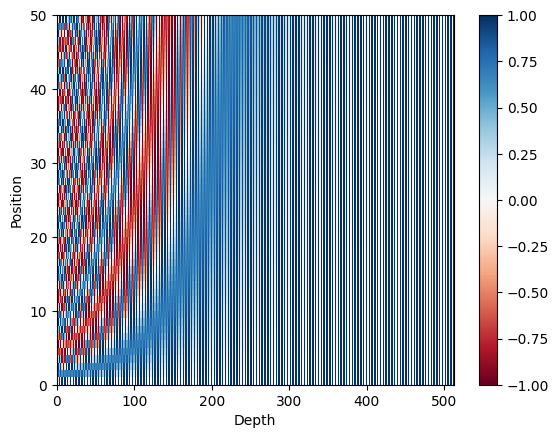

In [55]:
sample_pos_encoding = PositionalEncoding(50, 512)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [56]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

In [57]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


In [58]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [59]:
x = torch.tensor([[1, 2, 0, 3, 0],
                  [0, 0, 0, 4, 5]])
mask = create_padding_mask(x)
print("입력 텐서 크기 :", x.shape)    # (2, 5)
print("생성된 마스크 크기 :", mask.shape)  # (2, 1, 1, 5)
print(mask)

입력 텐서 크기 : torch.Size([2, 5])
생성된 마스크 크기 : torch.Size([2, 1, 1, 5])
tensor([[[[0., 0., 1., 0., 1.]]],


        [[[1., 1., 1., 0., 0.]]]])


In [60]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

In [61]:
x = torch.tensor([[1, 2, 3, 4, 5]])
mask_1 = create_look_ahead_mask(x)
print("첫 번째 시퀀스:\n", mask_1, mask_1.shape)

첫 번째 시퀀스:
 tensor([[[[0., 1., 1., 1., 1.],
          [0., 0., 1., 1., 1.],
          [0., 0., 0., 1., 1.],
          [0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [62]:
x2 = torch.tensor([[0, 5, 1, 5, 5]])
mask_2 = create_look_ahead_mask(x2)
print("두 번째 시퀀스:\n", mask_2, mask_2.shape)

두 번째 시퀀스:
 tensor([[[[1., 1., 1., 1., 1.],
          [1., 0., 1., 1., 1.],
          [1., 0., 0., 1., 1.],
          [1., 0., 0., 0., 1.],
          [1., 0., 0., 0., 0.]]]]) torch.Size([1, 1, 5, 5])


In [63]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


In [64]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

In [65]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [66]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

In [67]:
import os
# 코넬 대사 데이터셋 다운로드 URL
url = 'https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv'
filename = 'ChatbotData.csv'

# 이미 파일이 없는 경우에만 다운로드
if not os.path.exists(os.path.join(os.getenv('HOME'), filename)):
    print(f"Downloading {filename} ...")
    urllib.request.urlretrieve(url, os.path.join(os.getenv('HOME'), filename))
    print("Download complete.")


path_to_conversations = os.path.join(os.getenv('HOME'), filename)

print("path_to_conversations:", path_to_conversations)

path_to_conversations: /root/ChatbotData.csv


In [68]:

# with open(path_to_conversations, "r") as f:
#     raw = f.read().splitlines()
data = pd.read_csv(path_to_conversations, names=['query', 'answer', 'label'], header=1)
#
# print("Data Size:", len(raw))

print("Example:")
# Use .iloc to slice rows, then select the 'document' column
for sen in data['query'].iloc[0:100:20]:
    print(">>", sen)

Example:
>> 1지망 학교 떨어졌어
>> 가스비 장난 아님
>> 간만에 쇼핑 중
>> 감정컨트롤이 안돼
>> 개강옷 예쁘게 입어 볼까


In [69]:
# 사용할 샘플의 최대 개수
MAX_SAMPLES = 50000
print(len(data))

11822


Total Data Size: 11822
Data Size: 11661
문장의 최단 길이: 1
문장의 최장 길이: 56
문장의 평균 길이: 12


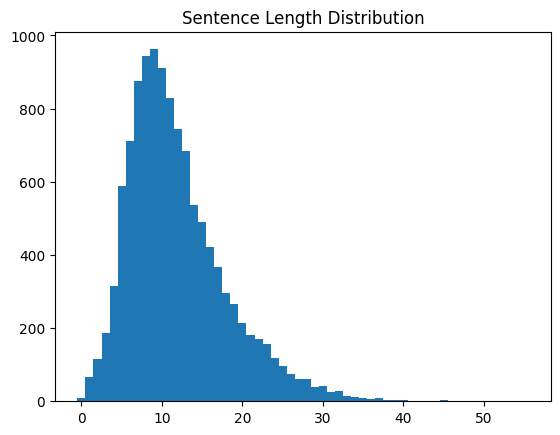

In [70]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(data['query']))  # set를 사용해서 중복을 제거합니다.

print("Total Data Size:", len(list(data['query'])))
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [71]:
import pandas as pd
import numpy as np
import sentencepiece as spm

def sp_tokenize_advanced(sp_processor, text, max_len=128):
    # 1. 토큰화 (숫자 인덱스로 변환)
    tokens = sp_processor.encode_as_ids(str(text))

    # 2. 길이 조절 (Trimming): 설정한 max_len보다 길면 자름
    tokens = tokens[:max_len]

    # 3. 패딩 처리: 부족한 길이를 pad_id(0)로 채움
    padding_length = max_len - len(tokens)
    tokens = tokens + ([0] * padding_length)
    # tokens + ([0] * padding_length) # post 뒤
    # [0] * padding_length + tokens # Pre-padding 앞

    return tokens

def load_data(train_data, test_data, vocab_size=10000, max_len=128):
    # 1. 데이터 클리닝
    train_data = train_data.drop_duplicates(subset=['query']).dropna(how='any')
    test_data = test_data.drop_duplicates(subset=['query']).dropna(how='any')

    # 2. SentencePiece 학습을 위한 코퍼스 생성
    with open('corpus.txt', 'w', encoding='utf-8') as f:
        for line in train_data['query']:
            f.write(str(line) + '\n')

    # 3. 모델 학습
    spm.SentencePieceTrainer.train(
        f'--input=corpus.txt --model_prefix=korean_spm --vocab_size={vocab_size} '
        f'--model_type=bpe --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 --minloglevel=2'
    )
    sp = spm.SentencePieceProcessor()
    sp.load('korean_spm.model')

    # 4. 고급 토큰화 적용 (Trimming + Padding)
    # 각 문장에 대해 sp_tokenize_advanced를 수행합니다.
    X_train = [sp_tokenize_advanced(sp, sentence, max_len) for sentence in train_data['document']]
    X_test = [sp_tokenize_advanced(sp, sentence, max_len) for sentence in test_data['document']]

    # 결과물을 numpy array로 변환 (모델 입력용)
    X_train = np.array(X_train)
    X_test = np.array(X_test)

    # 5. word_to_index 생성
    word_to_index = {sp.id_to_piece(i): i for i in range(sp.get_piece_size())}

    return X_train, np.array(train_data['label']), X_test, np.array(test_data['label']), word_to_index

X = data.drop(columns=['label'])  # Cleaned text data
y = data['label']  # 0 or 1 values
# 실행 (max_len 인자를 추가로 제어할 수 있습니다)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
# X_train, y_train, X_test, y_test, word_to_index = load_data(cleaned_corpus, max_len=64)

In [72]:
data

,query,answer,label
0,1지망 학교 떨어졌어,위로해 드립니다.,0
1,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
2,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
3,PPL 심하네,눈살이 찌푸려지죠.,0
4,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,0
...,...,...,...
11817,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11818,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11819,흑기사 해주는 짝남.,설렜겠어요.,2
11820,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


In [73]:
X_test

,query,answer
8169,죽을거같죠?사람은 간사하네,나쁜 생각 멈추세요.
900,내일 약속 있는데 날씨 좋았으면,날씨가 안 좋더라도 데이트는 성공적일 거예요.
8075,정말로 끝났네 이젠,놓아주세요.
7625,이별후 느끼는 감정들이 단계별로 있는거 같네,그게 이별의 흔적인가봐요.
2816,쌍커풀성형할까,돈 많이 들텐데요.
...,...,...
1745,못하는 게 없는 사람,그런 사람이 있으면 저 좀 소개시켜주세요.
10902,이거 썸 맞나,대화를 시작하는 사람이 누구인지 살펴보세요.
4902,푸르른 하늘을 보고 싶다,가끔 하늘을 보세요.
6662,"새사람을 만날 듯, 전 여친에게 미안해",미안해하지 않아도 돼요. 새사람에게 충실하세요.


In [74]:
def read_cornell_data(X_train):
    pairs = []
    for line in range(len(X_train) -1 ):
        #print(line)
        parts = X_train['query'][line]
        # 연속된 두 문장씩 (질문, 답변) 구성
        parts2 = X_train['answer'][line]
        #print(parts)
        #print(parts2)
        pairs.append( [parts, parts2] )
        #print(pairs)
    return pairs

In [75]:
corpus_file = os.path.join(os.getenv('HOME'), "clean_corpus.txt")
X_train_pairs = X_train.reset_index(drop=True)
pairs = read_cornell_data(X_train_pairs)
with open(os.path.join(os.getenv('HOME'),corpus_file), 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [76]:
file_url =  os.path.join(os.getenv('HOME'), "clean_corpus.txt")

spm.SentencePieceTrainer.Train(
    input=file_url,
    model_prefix="spm_cornell",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)


KeyboardInterrupt: 

In [ ]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_cornell.model")

In [ ]:
# 전처리 함수
def preprocess_sentence(sentence):
  # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^a-zA-Zㄱ-ㅎ가-힣?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence
print("슝=3")

In [ ]:
# 예제 문장
sentence = "엠티 가는데 짝남이랑 같은 조 됐으면 좋겠다."

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)


In [ ]:
class CornellDataset(Dataset):
    def __init__(self, pairs, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 4) 고정 길이 패딩
            q_tokens += [0]*(max_length - len(q_tokens))  # 0 -> <pad> 가정
            a_tokens += [0]*(max_length - len(a_tokens))

            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            #    (teacher forcing용)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

In [ ]:
dataset = CornellDataset(pairs, sp, max_length=40)

In [ ]:
for encoder_input, decoder_input, decoder_label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

In [ ]:
dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

In [ ]:
for encoder_input, decoder_input, decoder_label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

In [ ]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [ ]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기(예시)

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

In [ ]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [ ]:
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [ ]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=500))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [ ]:
def train_step(model, batch, optimizer, loss_function, device):

    current_lr = optimizer.param_groups[0]['lr']
    # print(f"Current LR: {current_lr}")
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

In [ ]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)

            total_loss += loss.item() if hasattr(loss, 'item') else loss
            total_acc += acc.item() if hasattr(acc, 'item') else acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()
        # 에폭별 평균 계산

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        # 히스토리에 현재 에폭의 평균 값 저장
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)

        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")
        # 3. 저장된 기록 반환
    return loss_history, acc_history

In [ ]:
%%time

train_loss, train_acc =train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=20,  # 원하는 에폭 수
    device=device
)

In [ ]:
def plot_metrics(loss_history, acc_history):
    epochs = range(1, len(loss_history) + 1)

    plt.figure(figsize=(12, 5))

    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_history, 'b-', label='Training Loss')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_history, 'r-', label='Training Accuracy')
    plt.title('Training Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# 2. 그래프 그리기
plot_metrics(train_loss, train_acc)

In [ ]:
def decoder_inference(model, sentence, tokenizer, device='cpu', temperature=1.0, top_k=10):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            # predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)
#-----------------------------
            # [수정된 부분] Argmax 대신 Sampling 적용
            # -----------------------------------------------------------
            # (1) Temperature 적용: 낮으면(0.5) 보수적, 높으면(1.2) 창의적
            logits = last_step_logits / temperature

            # (2) Top-k Filtering (선택 사항: 확률 낮은 이상한 단어 차단)
            if top_k > 0:
                top_k_probs, _ = torch.topk(logits, top_k)
                min_val = top_k_probs[:, -1].view(-1, 1) # k번째로 높은 확률값
                logits[logits < min_val] = -float('inf') # 그보다 낮은건 삭제

            # (3) Softmax로 확률 변환
            probs = F.softmax(logits, dim=-1)

            # (4) 확률 분포에 따라 랜덤 추출 (Multinomial)
            predicted_id = torch.multinomial(probs, num_samples=1)
            # -----------------------------------------------------------
            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            # predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [ ]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    # return predicted_sentence

In [77]:
sentence = 'Where have you been?'
sentence_generation(model, sentence, sp, device)

입력 : Where have you been?
출력 : 그 사람 말고 저랑 수다 떨어요.


In [78]:
sentence = "It's a trap"
sentence_generation(model, sentence, sp, device)

입력 : It's a trap
출력 : 이제 연락 하지 마세요.


In [79]:
sentence_generation(model, '영화 볼래?', sp, device)

입력 : 영화 볼래?
출력 : 좋은 시간 보내시길 바라요.


In [80]:

sentence_generation(model, "고민이 있어", sp, device)

입력 : 고민이 있어
출력 : 좋은 소식이네요.


In [81]:

sentence_generation(model, "너무 화가나", sp, device)

입력 : 너무 화가나
출력 : 좋은 일이 생길 거예요.


In [82]:

sentence_generation(model, "게임하고싶은데 할래?", sp, device)



입력 : 게임하고싶은데 할래?
출력 : 이제 좀 괜찮아졌길 바랍니다.


In [83]:
sentence_generation(model, "나 너 좋아하는 것 같아", sp, device)


입력 : 나 너 좋아하는 것 같아
출력 : 많이 지쳤나봐요.


In [84]:
sentence_generation(model, "딥 러닝 자연어 처리를 잘 하고 싶어", sp, device)


입력 : 딥 러닝 자연어 처리를 잘 하고 싶어
출력 : 잘 해결되길 바랄게요.


In [85]:
sentence_generation(model, "이름이 뭐야?", sp, device)


입력 : 이름이 뭐야?
출력 : 이제 내려주세요.


In [86]:
sentence_generation(model, "위로봇아 안녕", sp, device)


입력 : 위로봇아 안녕
출력 : 그런 날이 있더라고요.


In [87]:
sentence_generation(model, "사람? 어떤 사람이 되고 싶어?", sp, device)


입력 : 사람? 어떤 사람이 되고 싶어?
출력 : 그 사람이 좋아하는 걸 알아보세요.


In [88]:
sentence_generation(model, "어떤 관심?", sp, device)


입력 : 어떤 관심?
출력 : 더 좋은 사람 만나실 거예요.


In [89]:
sentence_generation(model, "아무말 대잔치네", sp, device)


입력 : 아무말 대잔치네
출력 : 이제 내려주세요.


In [90]:
sentence_generation(model, "날 위로해줘", sp, device)


입력 : 날 위로해줘
출력 : 좋은 만남이었길 바라요.


In [91]:
sentence_generation(model, "고마워", sp, device)


입력 : 고마워
출력 : 저도 듣고 싶네요.


## 아까 겪으셨던 '28%의 늪(Local Minima)'을 완전히 탈출하신 것이 확실합니다.
* optim.Adam의 lr=1.0 설정 없이는 이 코드가 제대로 작동하지 않아 지금과 같은 '학습 정체' 현상이 발생합니다.
  - Optimizer: lr=1.0 설정 추가
  - Scheduler: warmup_steps를 500 ~ 1000으로 단축



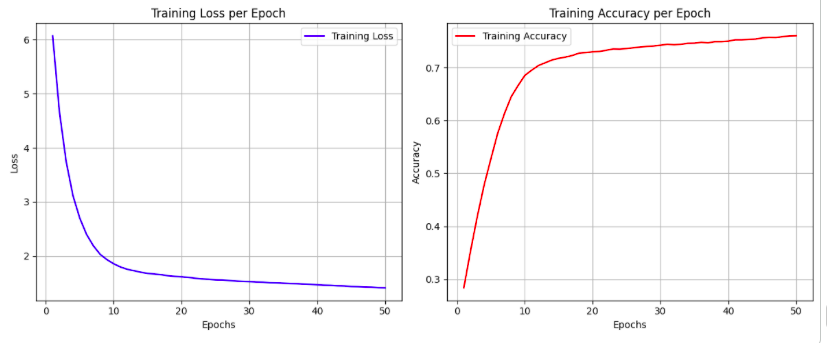

## 그래프가 아주 완벽합니다. 🎉
1. 초반의 급격한 변화 (0~10 Epoch)

* Loss: 6.0 → 2.0으로 수직 낙하했습니다.

* Accuracy: 28% → 70%까지 치솟았습니다.

의미: lr=1.0 설정과 warmup_steps 조정이 제대로 먹혀들었습니다. 모델이 이제야 가중치를 제대로 업데이트하며 데이터의 패턴을 "학습"하기 시작했다는 증거입니다.

2. 중후반의 안정적 수렴 (10~50 Epoch)

* Loss: 2.0에서 1.5 수준으로 완만하게 계속 떨어지고 있습니다.

* Accuracy: 70%에서 75~76%까지 꾸준히 오르고 있습니다.

의미: 학습이 불안정하지 않고 매우 이상적인 곡선(Smooth Curve)을 그리며 수렴하고 있습니다. 아주 건강한 학습 상태입니다.

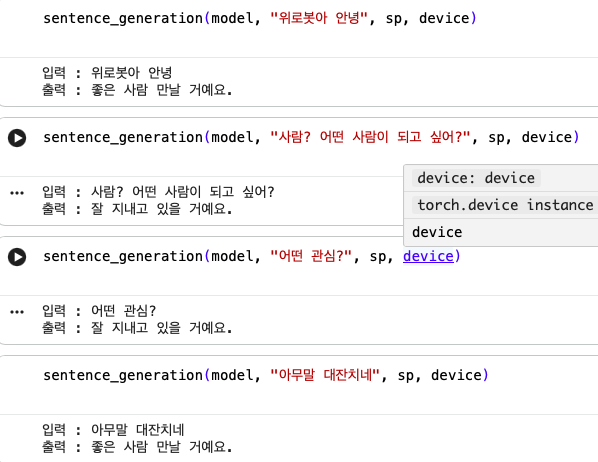

## 2가지 대답을 반복하고 있음

In [92]:
import pandas as pd

# 가정: df라는 데이터프레임이 있고, 정답 컬럼 이름이 'target'이라고 할 때
# df = pd.read_csv('train_data.csv')

# 상위 5개 값의 비율 확인0
top_5_stats = data['answer'].value_counts(normalize=True).head(10) * 100

print("📊 상위 5개 정답 문장 비율")
print("-" * 30)
for text, percent in top_5_stats.items():
    print(f"[{percent:.2f}%] {text}")

📊 상위 5개 정답 문장 비율
------------------------------
[0.19%] 맛있게 드세요.
[0.14%] 제가 있잖아요.
[0.12%] 조심하세요.
[0.12%] 감기 조심하세요.
[0.10%] 잘할 수 있을 거예요.
[0.10%] 직접 물어보세요.
[0.08%] 자연스러운 현상이에요.
[0.08%] 지금도 늦지 않았어요.
[0.08%] 네 말씀해주세요.
[0.08%] 맘고생 많았어요.
